In [3]:
import ydf
import numpy as np
import pandas as pd

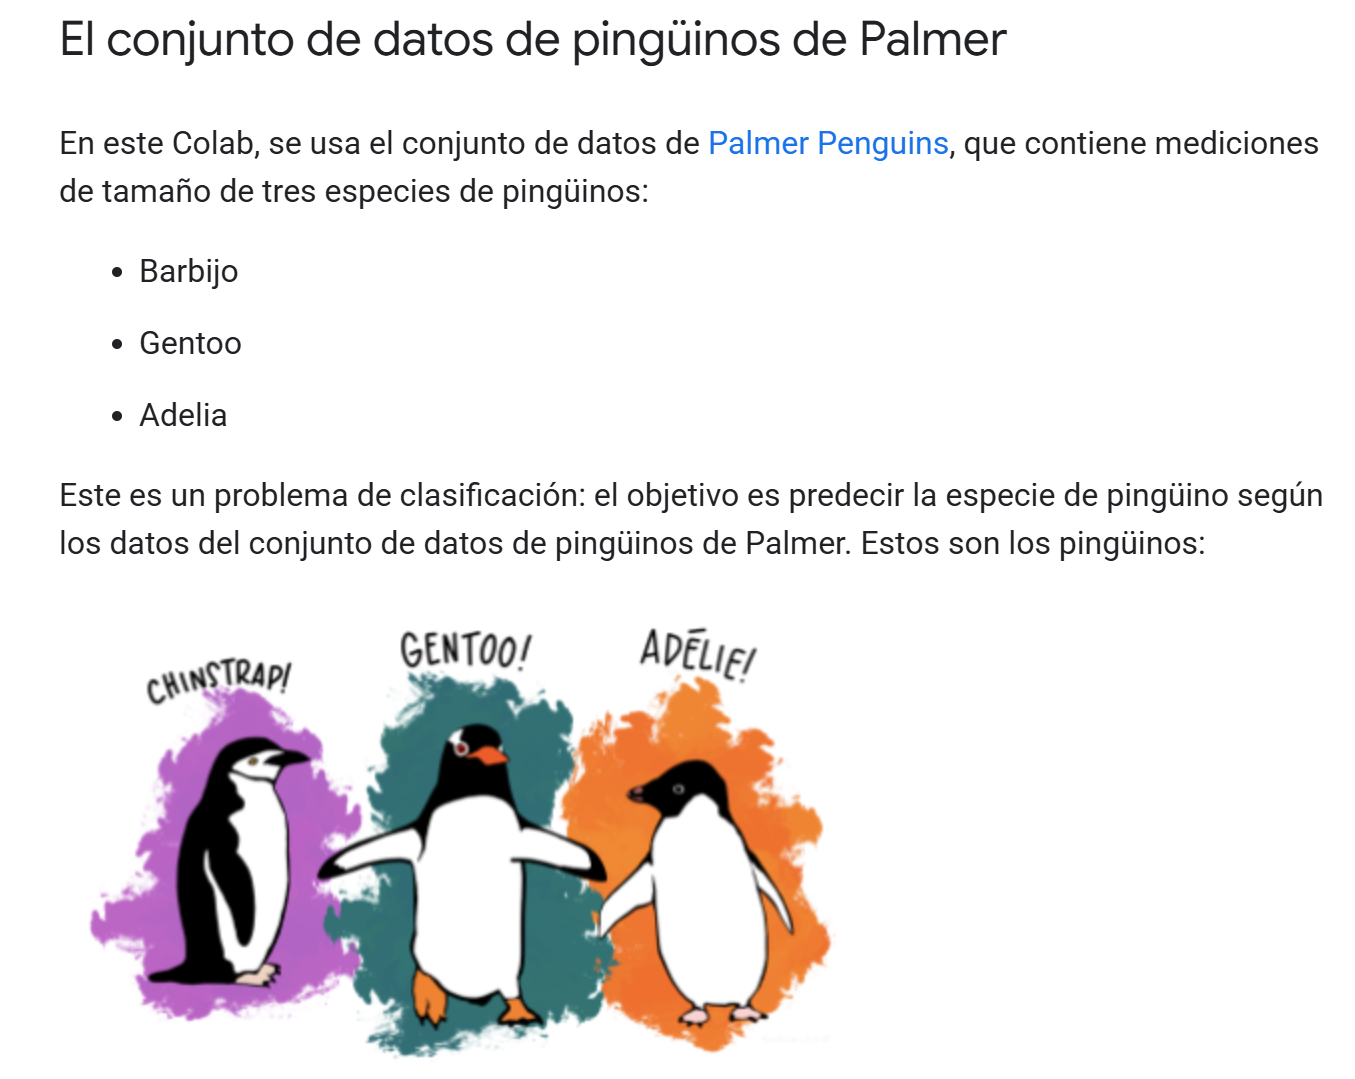

In [26]:

path = "https://storage.googleapis.com/download.tensorflow.org/data/palmer_penguins/penguins.csv"

dataset = pd.read_csv(path)
label = "species"

dataset.head(50)
#print(dataset.shape)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,female,2007
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,male,2007
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN,2007
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN,2007


| Variable            | Tipo        | Descripción                                  | Valores / Ejemplo                | Uso en EDA                          |
|--------------------|------------|----------------------------------------------|----------------------------------|-------------------------------------|
| species            | Categórica | Especie del pingüino                         | Adelie, Chinstrap, Gentoo        | Clasificación / variable objetivo    |
| island             | Categórica | Isla donde fue observado                     | Torgersen, Biscoe, Dream         | Segmentación geográfica              |
| bill_length_mm     | Numérica   | Longitud del pico (mm)                       | 39.1                             | Análisis de tamaño                   |
| bill_depth_mm      | Numérica   | Profundidad del pico (mm)                    | 18.7                             | Diferenciación entre especies        |
| flipper_length_mm  | Numérica   | Longitud de la aleta (mm)                    | 181                              | Relación con masa corporal           |
| body_mass_g        | Numérica   | Peso del pingüino (gramos)                   | 3750                             | Variable clave de análisis           |
| sex                | Categórica | Sexo del pingüino                            | male, female                     | Comparación por género               |
| year               | Numérica   | Año de registro                              | 2007, 2008, 2009                 | Análisis temporal                    |

In [18]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB




ARBOL INICIAL


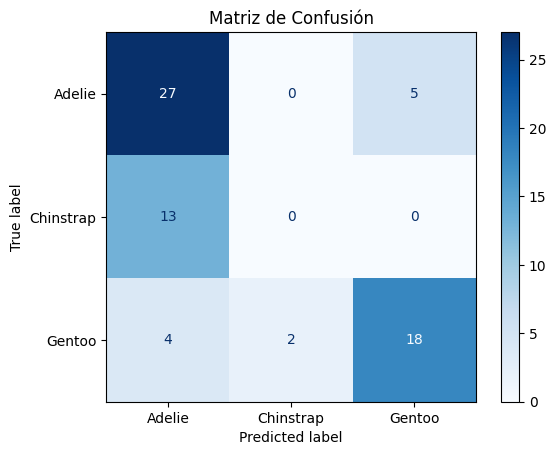

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

df = dataset

#X = df[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]]
X = df[[ "year", "body_mass_g"]]

y = df["species"]

# Train/Test   vemos despues aqui8 defino cuiando uso para entrenar y cuanto uso para testear
# random state es la semilla usen siempre la misma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2005)

#  Modelo
modelo = DecisionTreeClassifier(max_depth=3)
modelo.fit(X_train, y_train) # entreno

# Predicción
y_pred = modelo.predict(X_test)

#  Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

#  Visualización
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo.classes_)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión")
plt.show()

Valores faltantes

In [ ]:
dataset.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11
year,0


📊 Estadística descriptiva :
Permite analizar:Media,Desvío estándar,Valores mínimos y máximos

In [ ]:
dataset.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


El Análisis Univariado

El Análisis Univariado es uno de los primeros pasos en un EDA (Exploratory Data Analysis) y consiste en estudiar una sola variable a la vez para entender su comportamiento


 Es el análisis de una única variable del dataset sin considerar relaciones con otras variables.

 ¿Para qué sirve?

Permite:

✔ Entender cómo se distribuyen los datos
✔ Detectar valores extremos (outliers)
✔ Identificar errores o datos faltantes
✔ Resumir la información de una variable


**Distribución de variables numéricas**





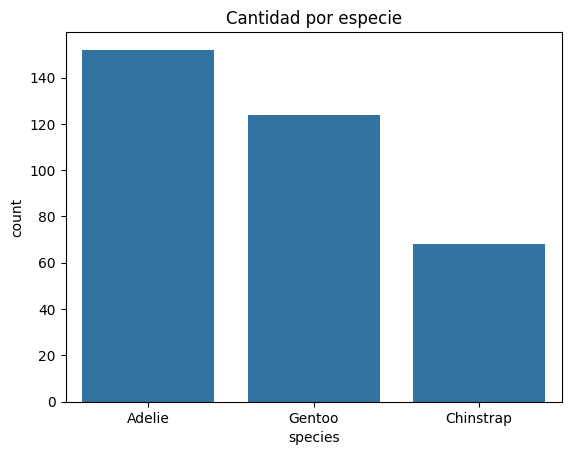

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt  # 👈 ESTA LÍNEA FALTABA


sns.countplot(data=dataset, x="species")
plt.title("Cantidad por especie")
plt.show()

Conteo de especies

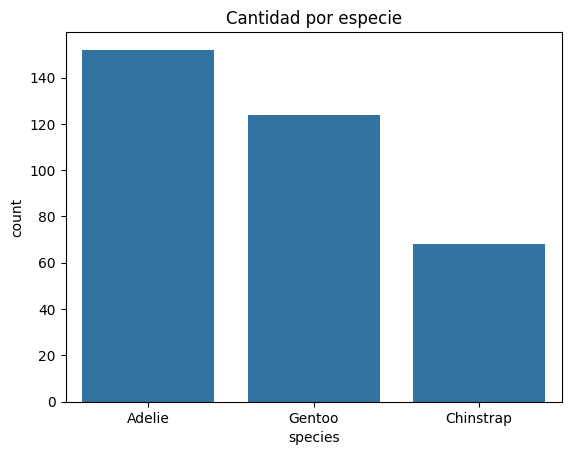

In [ ]:
sns.countplot(data=dataset, x="species")
plt.title("Cantidad por especie")
plt.show()

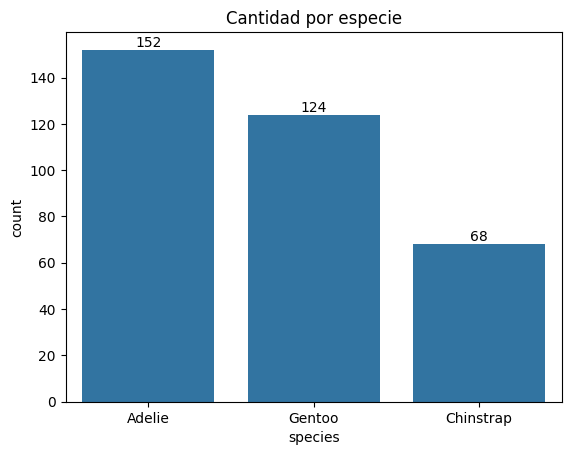

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.countplot(data=dataset, x="species")

# Agregar números arriba de cada barra
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )

plt.title("Cantidad por especie")
plt.show()

Análisis Bivariado
Es el análisis de la relación entre DOS variables del dataset.
 ¿Para qué sirve?

Permite:

✔ Detectar relaciones entre variables
✔ Encontrar patrones
✔ Identificar correlaciones
✔ Descubrir si una variable influye sobre otra


🔹 Relación entre variables (scatter)

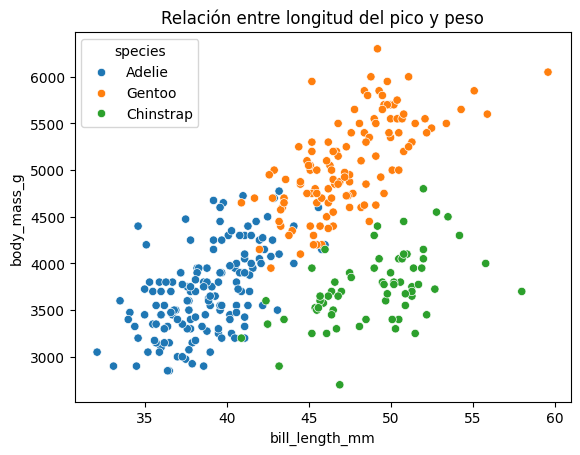

In [ ]:
sns.scatterplot(data=dataset, x="bill_length_mm", y="body_mass_g", hue="species")
plt.title("Relación entre longitud del pico y peso")
plt.show()



🔹 Boxplot (comparación por especie)




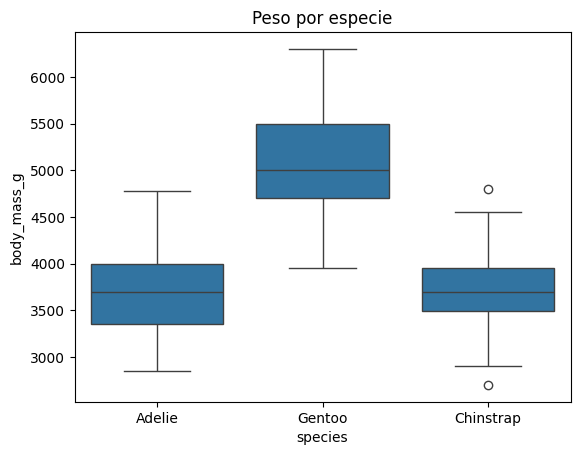

In [ ]:
sns.boxplot(data=dataset, x="species", y="body_mass_g")
plt.title("Peso por especie")
plt.show()

🔹 Relación categórica

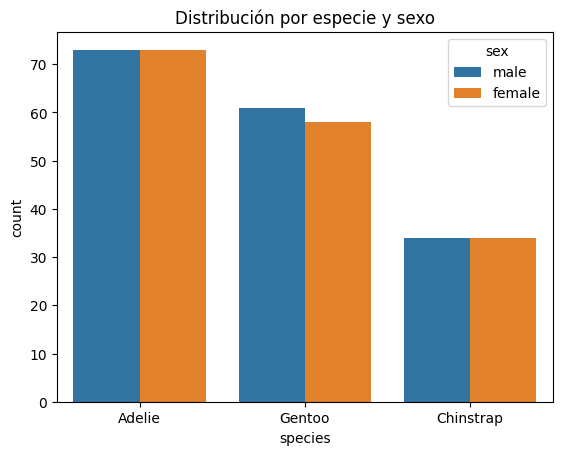

In [ ]:
sns.countplot(data=dataset, x="species", hue="sex")
plt.title("Distribución por especie y sexo")
plt.show()

Correlación

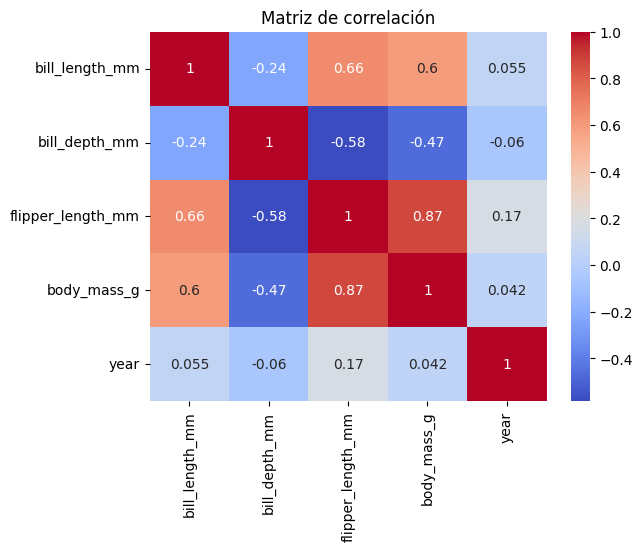

In [ ]:
sns.heatmap(dataset.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

## **Limpieza de datos**

In [ ]:
#EKIMINO NULOS
df_clean = dataset.dropna()


# O RELLENO
#df["sex"].fillna("unknown", inplace=True)

Tarea:

Consigna:

Identificar variables más importantes
Detectar outliers
Explicar qué variables ayudan a clasificar especies

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

df_clean = dataset.dropna()

X = df_clean[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]]
y = df_clean["species"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

modelo = DecisionTreeClassifier(max_depth=3)

modelo.fit(X_train, y_train)

print("Accuracy:", modelo.score(X_test, y_test))

Accuracy: 0.9402985074626866


 ¿Qué es la matriz de confusión?

 Es una tabla que compara:

✔ Valores reales
✔ Valores predichos

Permite evaluar qué tan bien funciona un modelo de clasificación.

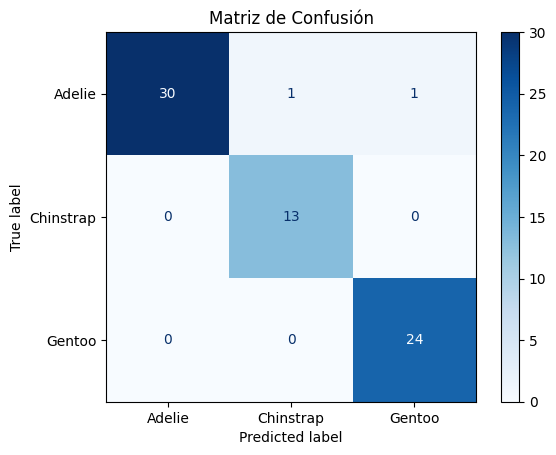

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#  1. Cargar dataset
df = dataset

# 3. Variables
X = df[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]]
y = df["species"]

#  4. Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  5. Modelo
modelo = DecisionTreeClassifier(max_depth=3)
modelo.fit(X_train, y_train)

#  6. Predicción
y_pred = modelo.predict(X_test)

#  7. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

#  8. Visualización
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo.classes_)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión")
plt.show()

# 📊 Evaluación de la bondad de un Árbol de Decisión 🌳

Además de la **matriz de confusión**, existen múltiples métricas para evaluar qué tan bueno es un modelo de clasificación.

---

# 1. Accuracy (Exactitud)

 Porcentaje de aciertos totales


```python
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)



In [22]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9710144927536232


#2. Precision


De los casos predichos como una clase, cuántos son correctos


In [23]:

from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred, average="weighted")
print("Precision:", precision)

Precision: 0.9726293995859214


Recall (Sensibilidad)

 De los casos reales, cuántos detecta correctamente



In [24]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred, average="weighted")
print("Recall:", recall)

Recall: 0.9710144927536232


F1-score

 Promedio entre precision y recall


 Muy usada en Machine Learning

In [25]:

from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred, average="weighted")
print("F1-score:", f1)

F1-score: 0.9709632541396382


In [13]:
Cohen’s Kappa (nivel avanzado 💣)

Mide acuerdo entre predicción y realidad, corrigiendo el azar


SyntaxError: invalid character '’' (U+2019) (3207928120.py, line 1)

In [15]:

from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(y_test, y_pred)
print("Kappa:", kappa)

Kappa: 0.9544554455445544


Importancia de las variables

In [16]:
import pandas as pd

importancias = pd.Series(modelo.feature_importances_, index=X.columns)
print(importancias.sort_values(ascending=False))

flipper_length_mm    0.555535
bill_length_mm       0.352444
bill_depth_mm        0.075536
body_mass_g          0.016485
dtype: float64
